# Quantum Noise Toolkit - Quickstart

This notebook walks through the full workflow on a 156-qubit IBM Heron device:
**calibration → hotspots → device maps → circuit reliability → noise channels → hardware validation → reports**.

It runs offline with `fake_fez`, a calibration snapshot of `ibm_fez`. With IBM Quantum credentials saved, replace it with `"ibm_fez"` for live data.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from qntoolkit import load_backend

backend = load_backend('fake_fez')   # or 'ibm_fez' for live calibration data

## 1. Calibration summary

Disabled qubits and couplers (error = 1.0) are counted separately and excluded from the averages.

In [2]:
from qntoolkit.characterization import backend_summary, qubit_properties

print(backend_summary(backend))
qubit_properties(backend).head()

Backend               : fake_fez
Qubits (faulty)       : 156 (0)
Native 1Q / 2Q Gates  : sx / cz
Couplers (faulty)     : 176 (7)
Average T1            : 145.3 us
Average T2            : 90.5 us
Average 1Q Error      : 2.87e-04
Average 2Q Error      : 5.56e-03
Average Readout Error : 1.32e-02


,t1_us,t2_us,frequency_ghz,readout_error,readout_duration_ns,single_qubit_error,two_qubit_error
qubit,,,,,,,
0,48.806208,42.379597,NaN,0.011475,1560.0,0.000764,0.010157
1,255.705171,302.790874,NaN,0.011719,1560.0,0.000178,0.006964
2,274.394256,99.984721,NaN,0.004883,1560.0,0.000198,0.003378
3,219.720452,215.543529,NaN,0.015869,1560.0,0.000239,0.003837
4,190.897112,161.932086,NaN,0.001465,1560.0,0.000212,0.003557


## 2. Best qubits and error hotspots

Hotspots are flagged with a robust (median absolute deviation) z-score, which the outliers themselves cannot inflate.

In [3]:
from qntoolkit.analysis import best_qubits, error_hotspots

print('Best qubits:', best_qubits(backend, 8))
error_hotspots(backend).head(10)

Best qubits: [80, 4, 23, 84, 126, 90, 96, 88]


,kind,location,metric,value,z_score
0,coupler,"(27, 28)",cz_error,1.000000,793.133551
1,coupler,"(32, 33)",cz_error,1.000000,793.133551
2,coupler,"(31, 32)",cz_error,1.000000,793.133551
3,coupler,"(68, 69)",cz_error,1.000000,793.133551
4,coupler,"(80, 81)",cz_error,1.000000,793.133551
5,coupler,"(139, 155)",cz_error,1.000000,793.133551
6,coupler,"(106, 107)",cz_error,1.000000,793.133551
7,coupler,"(153, 154)",cz_error,0.050049,36.743010
8,qubit,"(75,)",single_qubit_error,0.002488,30.081685
9,coupler,"(71, 72)",cz_error,0.039803,28.584862


## 3. Device maps

Faulty couplers are drawn dashed red.

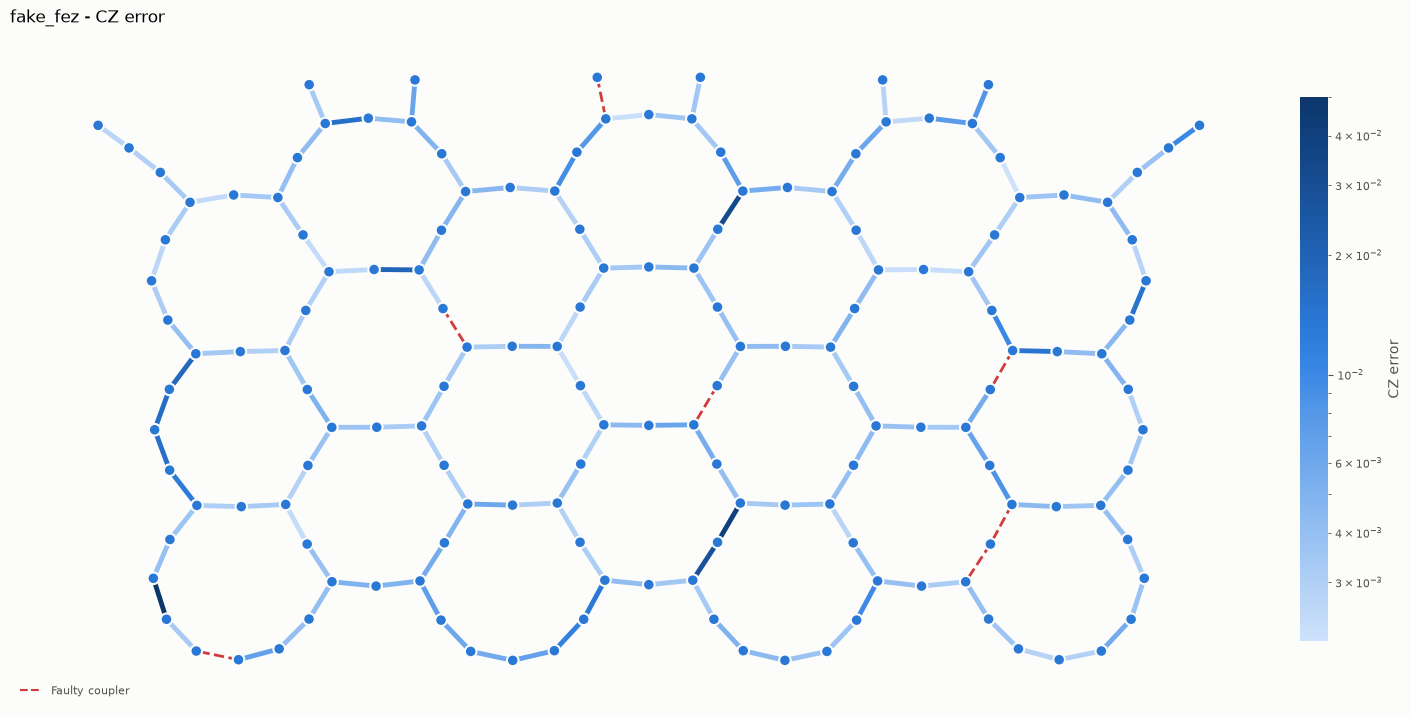

In [4]:
from qntoolkit.visualization import plot_cx_error_map, plot_t1_heatmap

plot_cx_error_map(backend);

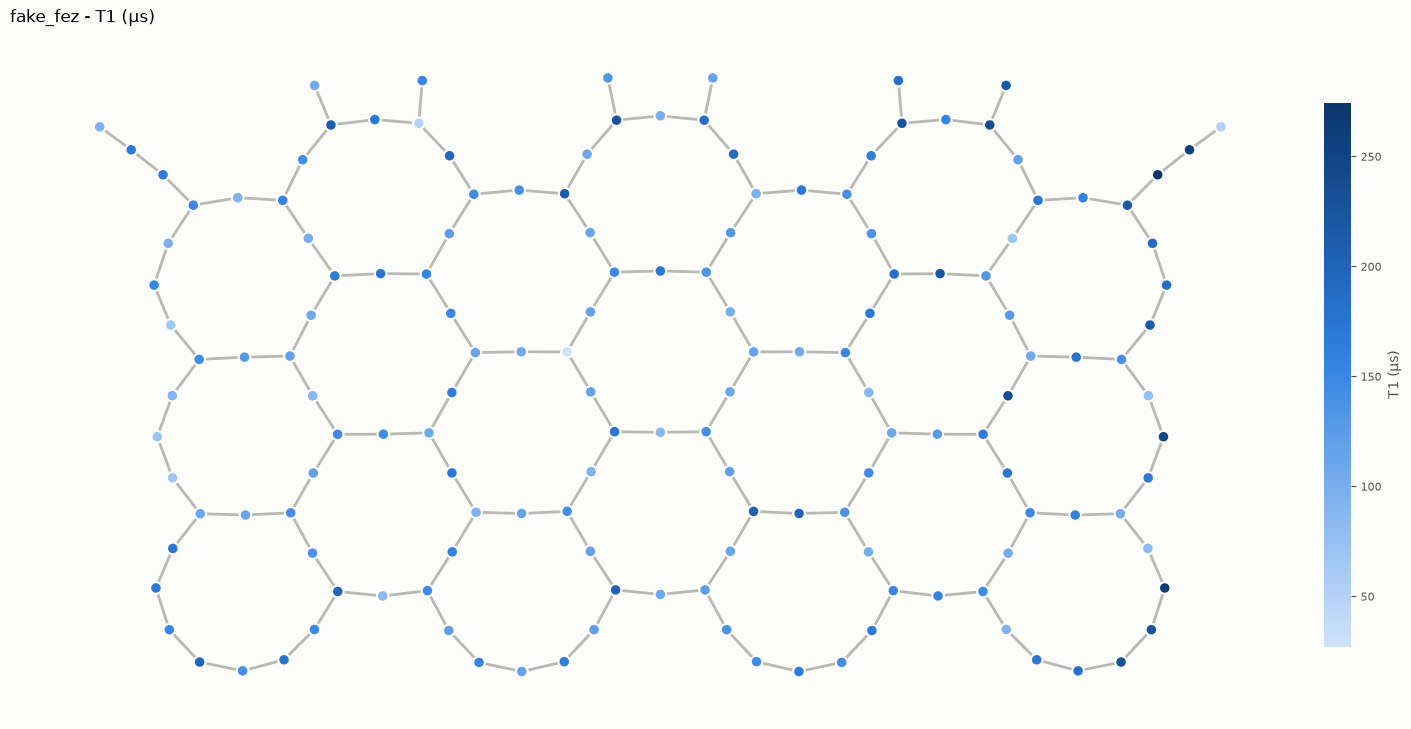

In [5]:
plot_t1_heatmap(backend);

## 4. Will my circuit work? Estimate before running

`analyse_circuit` transpiles the circuit, then multiplies `(1 - error)` for every gate and measurement on the physical qubits actually used. `include_idle=True` also charges T1/T2 decoherence while qubits wait.

In [6]:
from qiskit import QuantumCircuit
from qntoolkit.analysis import analyse_circuit

def ghz(n):
    qc = QuantumCircuit(n, name=f'ghz_{n}')
    qc.h(0)
    for q in range(n - 1):
        qc.cx(q, q + 1)
    qc.measure_all()
    return qc

print(analyse_circuit(ghz(5), backend, seed_transpiler=1, include_idle=True))

Circuit              : ghz_5
Backend              : fake_fez
Physical Qubits      : [0, 1, 2, 3, 4]
Depth                : 20
Two-Qubit Depth      : 4
Gate Counts          : {'rz': 18, 'sx': 9, 'measure': 5, 'cz': 4, 'barrier': 1}
Two-Qubit Gate Count : 4
Estimated Duration   : 2016 ns
Estimated Fidelity   : 0.9717
Estimated Error      : 0.0283
Success Probability  : 0.9283
Circuit Reliability  : 92.8/100 (excellent)


Which device suits the circuit best?

In [7]:
from qntoolkit.analysis import backend_suitability

devices = [load_backend(name) for name in ('fake_fez', 'fake_torino', 'fake_brisbane')]
backend_suitability(ghz(8), devices, seed_transpiler=1)

,rank,depth,two_qubit_gates,estimated_fidelity,success_probability,reliability
backend,,,,,,
fake_fez,1,32,7,0.953312,0.878820,good
fake_torino,2,32,7,0.966492,0.665457,fair
fake_brisbane,3,24,7,0.906509,0.626525,fair


## 5. Noise channels

Channels plug into Aer and `qiskit.quantum_info`.

In [8]:
import numpy as np
from qntoolkit.metrics import gate_fidelity, purity
from qntoolkit.noise_models import AmplitudeDamping, PhaseDamping, ThermalRelaxation

excited = np.array([0, 1])
print('Amplitude damping |1> ->', AmplitudeDamping(0.3).apply(excited).probabilities())

decay = AmplitudeDamping(0.1).compose(PhaseDamping(0.2))
print('Composed channel: gate fidelity', round(gate_fidelity(decay), 4))

# T1 = 100 us, T2 = 80 us, 1 us of idling
print('1 us idle fidelity:', round(gate_fidelity(ThermalRelaxation(100, 80, 1)), 5))

Amplitude damping |1> -> [0.3 0.7]
Composed channel: gate fidelity 0.9328
1 us idle fidelity: 0.9942


## 6. Validation on real hardware

Bell, GHZ-3 and GHZ-5 circuits were run on **ibm_fez** (job `dams55o2fm4c73f3f2k0`, 4000 shots each) with `examples/hardware_validation.py`.

In [9]:
import json
import pandas as pd

data = json.load(open('../docs/results/ibm_fez_validation.json'))
pd.DataFrame(data['results'])[
    ['circuit', 'physical_qubits', 'estimated', 'estimated_with_idle', 'simulated', 'hardware']
].round(3)

,circuit,physical_qubits,estimated,estimated_with_idle,simulated,hardware
0,bell,"[142, 143]",0.987,0.987,0.988,0.983
1,ghz_3,"[142, 143, 144]",0.978,0.978,0.979,0.976
2,ghz_5,"[140, 141, 142, 143, 144]",0.958,0.955,0.959,0.929


The estimate matches hardware to within 0.4 percentage points for Bell and GHZ-3. For GHZ-5 the per-qubit diagnosis traces most of the 3-point gap to a single qubit:

In [10]:
ghz5 = data['results'][2]
pd.DataFrame(ghz5['diagnosis'])[['qubit', 'hardware_flip_rate', 'simulated_flip_rate']].round(4)

,qubit,hardware_flip_rate,simulated_flip_rate
0,140,0.0330,0.0109
1,141,0.0068,0.0068
2,142,0.0040,0.0058
3,143,0.0052,0.0055
4,144,0.0058,0.0057


Qubit 140 failed on its own in 3.3% of shots versus 1.1% predicted by its calibration, consistent with a T1 fluctuation between calibration and execution; idle decoherence accounts for only 0.3 points. See [docs/hardware_validation.md](../docs/hardware_validation.md).

## 7. Reports

In [11]:
from qntoolkit.reports import generate_backend_report

report = generate_backend_report(backend)
print(report.to_markdown()[:900])

# Backend report: fake_fez

_Generated 2026-09-18 23:41:14 UTC_

## Summary

| Property | Value |
|---|---|
| num qubits | 156 |
| single qubit gate | sx |
| two qubit gate | cz |
| num couplers | 176 |
| num faulty qubits | 0 |
| num faulty couplers | 7 |
| mean t1 us | 145.3 |
| median t1 us | 144.9 |
| mean t2 us | 90.46 |
| median t2 us | 87.95 |
| mean readout error | 0.01324 |
| mean single qubit error | 2.871e-04 |
| mean two qubit error | 0.00556 |
| backend score (0-100) | 98.1 |

## Average gate fidelity

| Property | Value |
|---|---|
| cz | 0.9944 |
| rz | 1 |
| sx | 0.9997 |
| x | 0.9997 |

## Calibration statistics

| metric | count | mean | std | min | median | max |
|---|---|---|---|---|---|---|
| t1_us | 156 | 145.3 | 45.1 | 27.15 | 144.9 | 274.4 |
| t2_us | 156 | 90.46 | 52.89 | 5.986 | 87.95 | 302.8 |
| frequency_ghz | 0 | n/a | n/a | n/a | n/a | n/a |
| readout_error 